# Rastair built-in model evaluation

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(caret)
  library(furrr)
  library(doParallel)
  library("ggVennDiagram")
})
params <- list(threads=8,
               test_chr="chr16",
               rastair2 = "/users/ludwig/ikb109/Code/rastair2/target/release/rastair2",
               test_fasta = "/well/ludwig/shared/genomes/hg38_full_no-alt_spike-ins.fa.gz",
               test_bam = "/well/ludwig/projects/OAC_Trial/Tissue/TAPS/Alignments/069-004_ScrBsl_duodenum_md.bam",
               truth_vcf = "/well/ludwig/projects/OAC_Trial/Tissue/WGS/AB/AnnotatedGermlineVCFs/069-004:ScrBsl:duodenum.annotated.vcf.gz",
               work_dir = "/well/ludwig/users/ikb109/rastair2_test",
               ml_threshold = 0.8
               )
setwd(params$work_dir)

## Load data

In [15]:
truth.set <- fread(cmd=paste0("bcftools query -r ", params$test_chr, " -f '%CHROM\\t%POS\\t%REF\\t%ALT[\\t%GT]\\n' -i 'TYPE=\"SNP\" & FILTER=\"PASS\"' ", params$truth_vcf), header=FALSE, stringsAsFactors = TRUE)
setnames(truth.set, c("chr", "pos", "ref", "alt", "genotype"))

# subset truth set to regions that could have been called at all - not fair to compare regions without coverage
setkey(truth.set, chr, pos, ref, alt)

Run rastair2 call and extract relevant info

In [5]:
tmp_vcf = paste0(params$work_dir, "/", params$test_chr, "_", gsub(".bam", ".vcf.gz", basename(params$test_bam)))
if( ! file.exists(tmp_vcf)) {
	system2(params$rastair2, c("call", "-o", tmp_vcf, "-@", params$threads, "--ml", params$ml_threshold, "-l", params$test_chr, "-r", params$test_fasta, params$test_bam))
}
predictions.r2 <- fread(cmd=paste0("bcftools query -f '%CHROM\\t%POS\\t%REF\\t%ALT\\t%FILTER\\t%CPG\\t%CPGnovo[\\t%DP\\t%ML]\\n' ", tmp_vcf), header=FALSE, stringsAsFactors=TRUE, na.strings = c(".", "", "NA", "NaN", "*", "<*>"))
setnames(predictions.r2, c("chr", "pos", "ref", "alt", "filter", "cpg", "dn_cpg", "depth", "score"))

In [7]:
split_multiallelics <- function(dt) {
  if (nrow(dt) == 0) {
    return(list(ref=NA, alt=NA, score=NA))
  }
  alleles <- strsplit(as.character(dt$alt), ",")[[1]]
  scores <- strsplit(as.character(dt$score), ",")[[1]]

  # compose new table for returning
  output <- list(ref=rep(dt$ref, length(alleles)),
                 alt=alleles,
                 score=as.numeric(scores))

  return(output)
}

predictions.r2[is.na(cpg), cpg := 0]
predictions.r2[is.na(dn_cpg), dn_cpg := 0]
predictions.r2 <- predictions.r2[!is.na(alt) & ref!="N"]

predictions.r2[, g := cut(predictions.r2$pos, 100)]

plan(multisession, workers = params$threads)
predictions.r2 <- rbindlist(future_map(split(predictions.r2, by="g"), function(subtable){
        x <- subtable[, split_multiallelics(.SD), by=.(chr, pos, depth, cpg, dn_cpg, filter)]
        return(x)
      }
    )
)
# Close threads
plan(sequential)
predictions.r2 <- predictions.r2[!is.na(ref)]
predictions.r2[, chr := as.factor(chr)]
predictions.r2[, ref := as.factor(ref)]
predictions.r2[, alt := as.factor(alt)]

## Compare overlap of calls

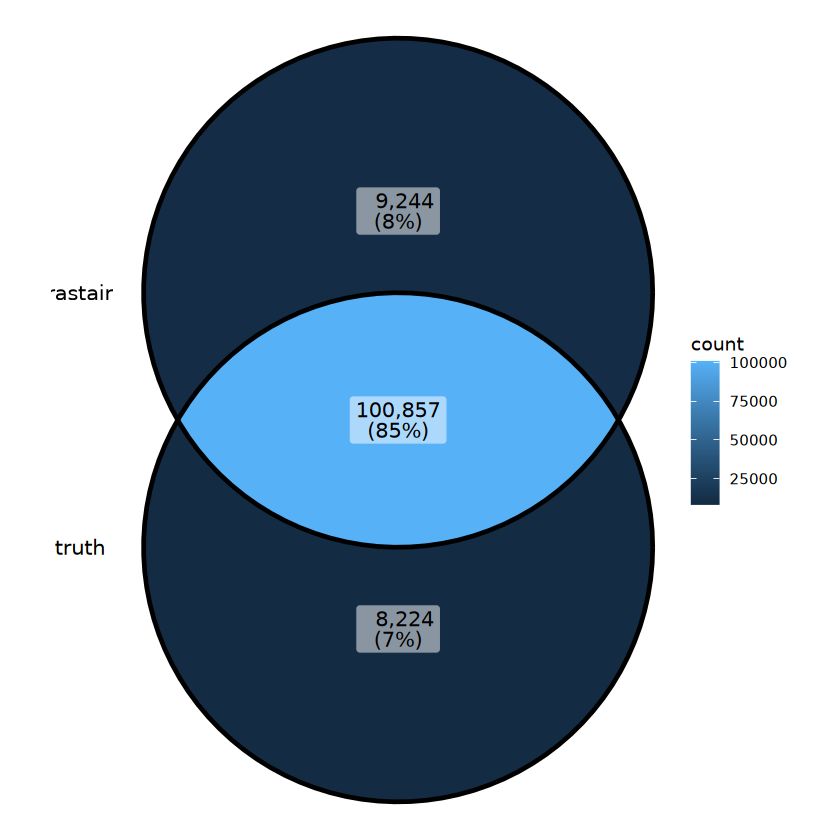

In [17]:
setkey(truth.set, chr, pos, ref, alt)
setkey(predictions.r2, chr, pos, ref, alt)

ggVennDiagram(list(truth=truth.set[chr==params$test_chr, paste0(chr, ":", pos, " ", ref, ">", alt)], rastair=predictions.r2[score > params$ml_threshold, paste0(chr, ":", pos, " ", ref, ">", alt)]))

This is quite good.

Let's calculate the statistics properly:

In [ ]:
# this excludes a certain number of positions in truth.set for which there's no row at all in predictions,
# ie we are only considering the ones for which there's evidence
predictions.r2.true <- truth.set[, .(chr, pos, ref, alt, type="SNP")][predictions.r2]
predictions.r2.true[is.na(type), type := "REF"]
predictions.r2.true[, type := as.factor(type)]

cm.stats <- confusionMatrix(predictions.r2.true[, as.factor(fifelse(score > params$ml_threshold, "SNP", "REF"))], reference = predictions.r2.true$type, positive="SNP")
cm.stats

Confusion Matrix and Statistics

          Reference
Prediction      REF      SNP
       REF 10227137     7715
       SNP     9244   100857
                                          
               Accuracy : 0.9984          
                 95% CI : (0.9983, 0.9984)
    No Information Rate : 0.9895          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9216          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.928941        
            Specificity : 0.999097        
         Pos Pred Value : 0.916041        
         Neg Pred Value : 0.999246        
             Prevalence : 0.010495        
         Detection Rate : 0.009749        
   Detection Prevalence : 0.010643        
      Balanced Accuracy : 0.964019        
                                          
       'Positive' Class : SNP             


What fraction of reference SNPs would not have been callable at all in TAPS due to lack of coverage/evidence?

In [ ]:
predictions.r2[truth.set[, .(chr, pos, ref, alt, type="SNP")]][is.na(score), .N]

[1] 423

Let's plot the fraction of real SNPs that are called correctly by type:

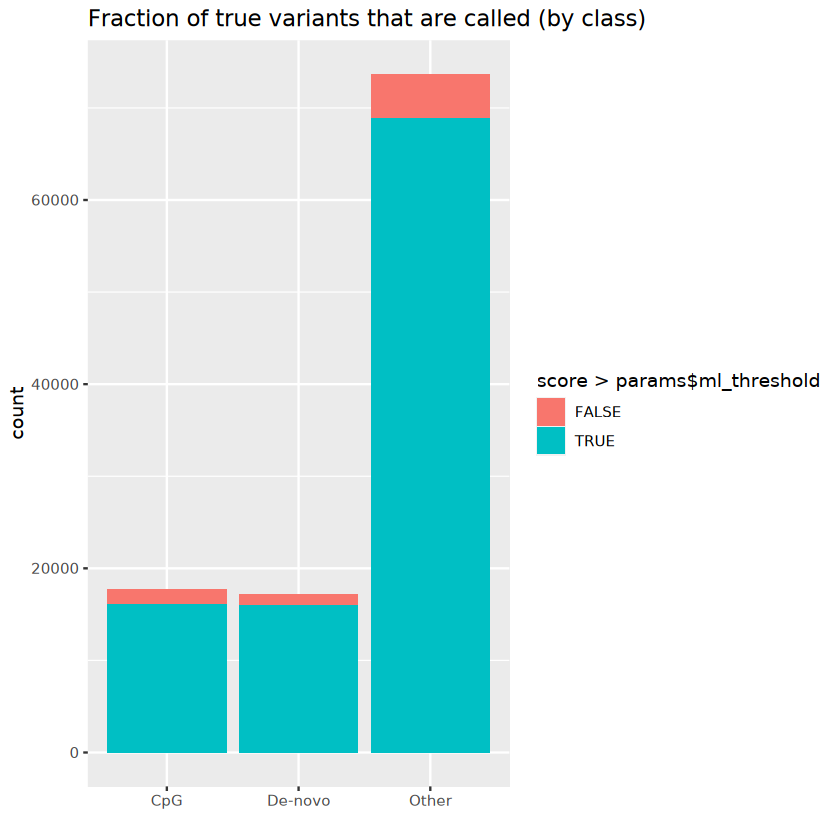

In [10]:
ggplot(predictions.r2.true[type=="SNP"], aes(x=ifelse(cpg, "CpG", ifelse(dn_cpg, "De-novo", "Other")), fill=score>params$ml_threshold)) + geom_bar() + xlab("") + ggtitle("Fraction of true variants that are called (by class)")

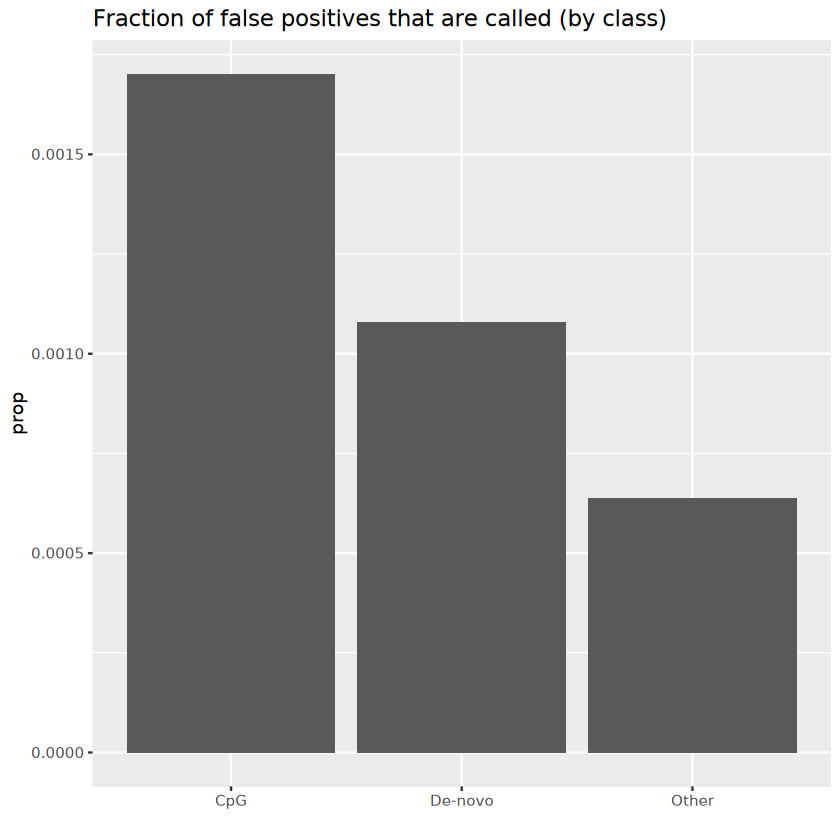

In [25]:
ggplot(predictions.r2.true[type=="REF", .(prop=sum(score>0.8)/.N), by=.(type=fifelse(cpg==1, "CpG", fifelse(dn_cpg==1, "De-novo", "Other")))], aes(x=type, y=prop)) + geom_bar(stat="identity") + xlab("") + ggtitle("Fraction of false positives that are called (by class)")

A tiny fraction!